<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/exercises/ImageProcessingEx_02_ImageEnhancement_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">

# מטלה 2 - פתרון:

<dir>

In [1]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL
import random
from scipy.signal import convolve

In [2]:
random.seed(3)

In [3]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, file_name)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [4]:
def plot_images(img:np.array, img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(28, 10))
    axes[0].imshow(img,  cmap='gray')
    axes[1].imshow(img1,  cmap='gray')
    axes[2].imshow(img2,  cmap='gray')

In [5]:
def sp_noise(img:np.array, d:float=0.003) -> np.array:
    '''
    add 'salt & pepper' noise with density d to an image, imnoise first assigns
    each pixel a random probability value from a standard uniform distribution
    on the open interval (0, 1).
    For pixels with probability value in the range (0, d/2), the pixel value is
      set to 0. The number of pixels that are set to 0 is
      approximately d*numel(I)/2.
    For pixels with probability value in the range [d/2, d), the pixel value is
      set to the maximum value of the image data type. The number of pixels that
      are set to the maximum value is approximately d*numel(I)/2.
    For pixels with probability value in the range [d, 1), the pixel value is
      unchanged.
    Args:
        img: image in float format (range: 0..1)
    Returns:
        img1: in float format (range: 0..1) - s&p noised image
    '''
    img1 = img.copy()
    nrows, ncols = img.shape
    for i in range(nrows):
        for j in range(ncols):
            rdn = random.random()
            if rdn <= d/2:
                img1[i][j] = 0.0
            elif d/2 < rdn < d:
                img1[i][j] = 1.0
            else:
                img1[i][j] = img[i][j]
    return img1

In [6]:
img = read_file(file_name='house.tiff')

## `my_median`

In [7]:
def my_median(img: np.array, filter_nrows:int, filter_ncols:int) -> np.array:
    '''
    This function applies a median filter of size (rows, cols) and returns the
    new image as a result.
    Args:
        img: image in float format (range: 0..1) - the image to enhance
        filter_nrows: number of rows of the median filter.
        filter_ncols: number of columns of the median filter.

    Returns:
        img_new: in float format (range: 0..1) - the enhanced image
    '''
    ######################################################################
    # TODO: Implement image enhancement using median filter.
    ######################################################################
    img_nrows, img_ncols = img.shape
    pad_nrows = filter_nrows // 2
    pad_ncols = filter_ncols // 2
    imiddle = (filter_nrows*filter_ncols)//2 # median index

    # creating img_p which is img and bounding zero padding
    img_p = np.zeros((img_nrows + filter_nrows -1, img_ncols + filter_ncols-1))
    img_p[pad_nrows:pad_nrows+img_nrows,pad_ncols:pad_ncols+img_ncols] = img

    img_new = np.zeros(shape=(img_nrows, img_ncols))
    for r in range(img_nrows):
        for c in range(img_ncols):
            # flatten the filtered area into a vector
            vec = img_p[r:r+filter_nrows, c:c+filter_ncols].reshape(
                filter_nrows*filter_ncols)
            sorted_vec = np.sort(vec)
            img_new[r,c] = sorted_vec[imiddle]
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

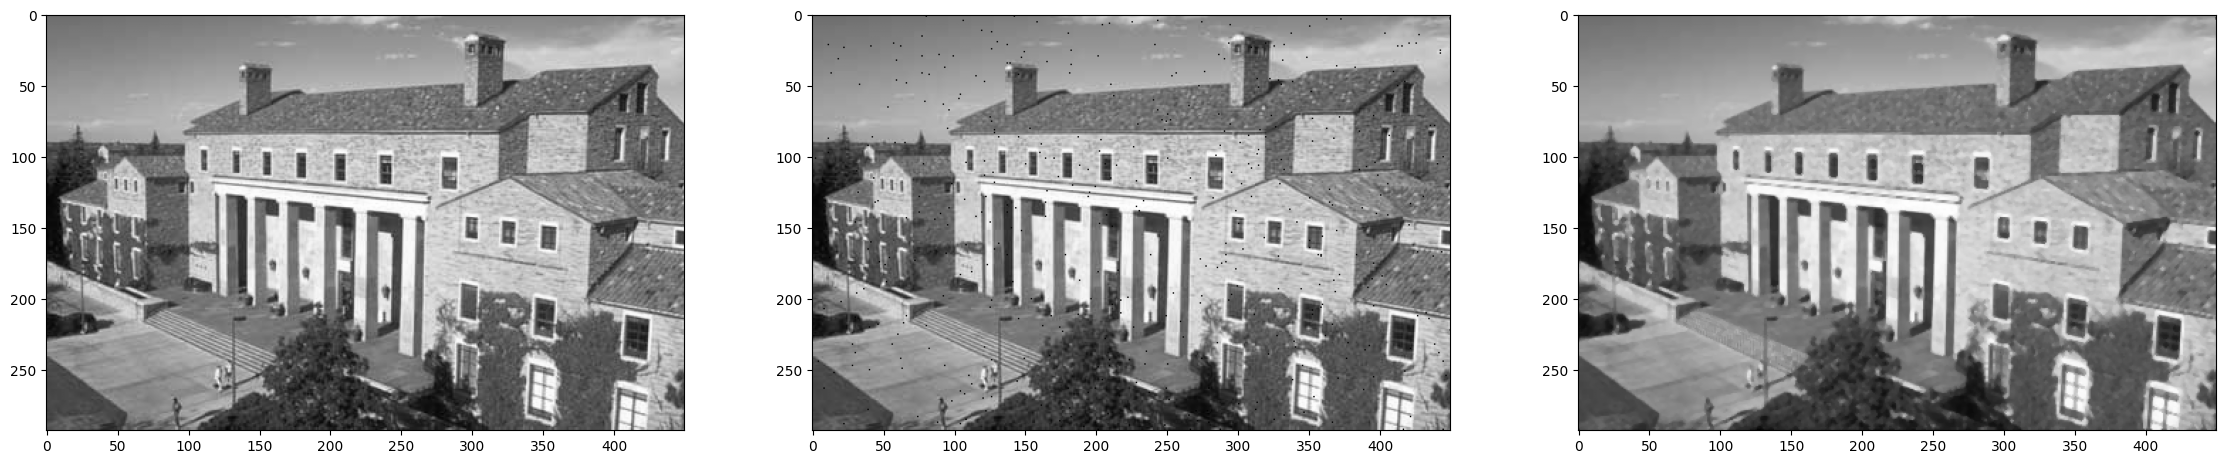

In [8]:
img_sp = sp_noise(img, d=0.003)
img_sp_e = my_median(img_sp, 3, 3)
plot_images(img/255, img_sp, img_sp_e)

## `gauss_enhance`

In [9]:
def gauss_enhance(img: np.array) -> (np.array, np.array):
    '''
    This function receives an image and add gaussian noise to the image with
    mean value 0.0, and var=0.04, and then try to enhance the image using the
    directional smoothing as explained in the class. It is up to you, to choose
    the right directional filters (size, orientation, and values). On the
    docstring of this function you should write which filters does this function
    use.
    Args:
        img: in float format (range: 0..1) - the image to enhance

    Returns:
        img_e: in float format (range: 0..1) - the enhanced image.
        img_n: in float format (range: 0..1) - the noisy image.
    '''
    ######################################################################
    # TODO: Implement image enhancement using Gaussian filter.
    ######################################################################
    img_n = img.copy()
    nrows, ncols = img_n.shape
    for r in range(nrows):
        for c in range(ncols):
            img_n[r,c] += np.random.normal(0.0, 0.04)
    img_n = np.clip(img_n, a_min=0.0, a_max=1.0)

    mask1 = np.ones((5,5))/25
    mask2 = np.eye(5)/5             # diagonal bar
    mask3 = np.flip(np.eye(5)/5)    # reversed diagonal
    h = np.zeros((5,5))
    h[3,:] = 1
    mask4 = h/5                     # horizontal bar
    v = np.zeros((5,5))
    v[:,3] = 1
    mask5 = v/5                     #vertical bar
    mask6 = np.eye(9)/9             # diagonal bar
    mask7 = np.flip(np.eye(9)/9)    # reversed diagonal
    mask8 = np.ones((7,7))/49

    conv1 = convolve(in1=img_n, in2=mask1, mode="same")
    conv2 = convolve(in1=img_n, in2=mask2, mode="same")
    conv3 = convolve(in1=img_n, in2=mask3, mode="same")
    conv4 = convolve(in1=img_n, in2=mask4, mode="same")
    conv5 = convolve(in1=img_n, in2=mask5, mode="same")
    conv6 = convolve(in1=img_n, in2=mask6, mode="same")
    conv7 = convolve(in1=img_n, in2=mask7, mode="same")
    conv8 = convolve(in1=img_n, in2=mask8, mode="same")

    img_e = np.zeros((nrows, ncols))
    for r in range(nrows):
        for c in range(ncols):
            convs = [conv1[r,c], conv2[r,c], conv3[r,c], conv4[r,c],
                     conv5[r,c], conv6[r,c], conv7[r,c], conv8[r,c]]
            dists = abs(convs - img_n[r,c])
            min_ind = dists.argmin()
            img_e[r, c] = convs[min_ind]
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_e, img_n

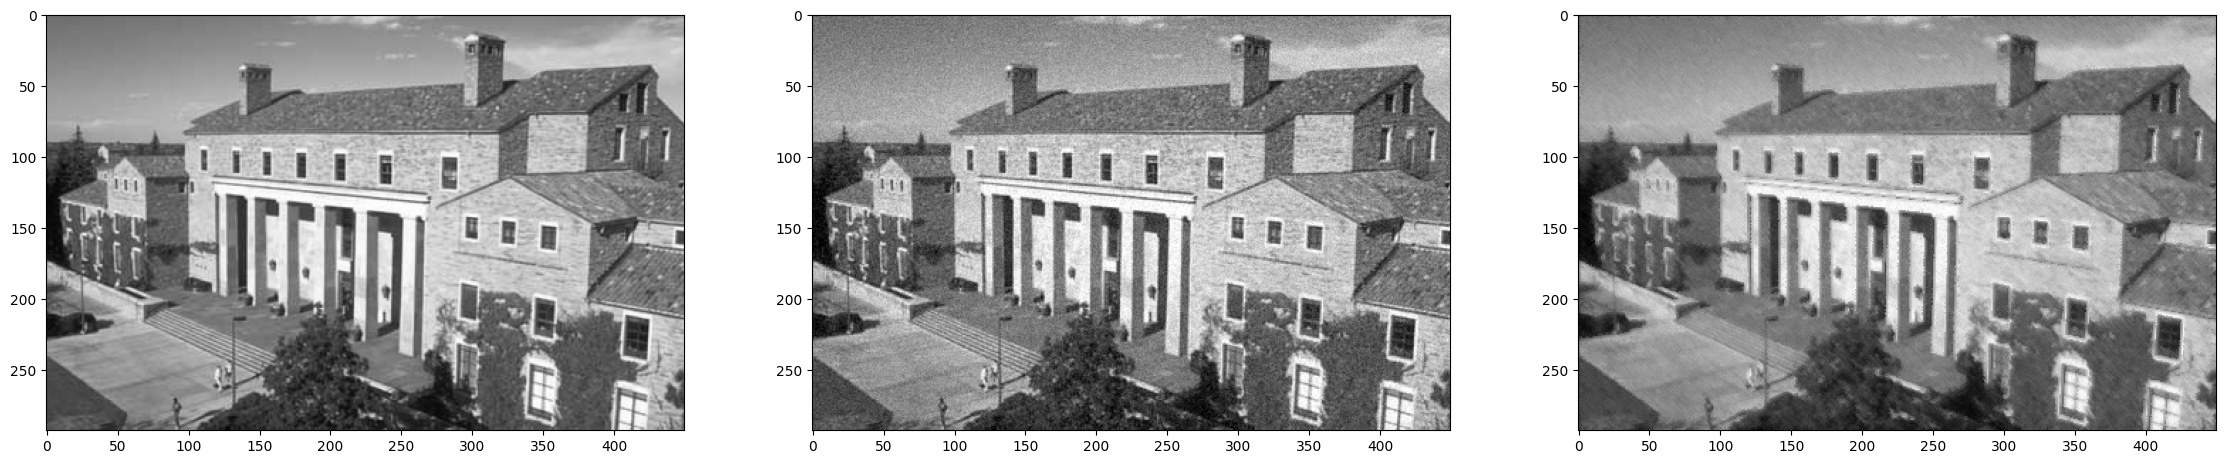

In [10]:
img_e, img_n = gauss_enhance(img / 255.0)
plot_images(img/255.0, img_n, img_e)

##shapes_enhance

In [11]:
def shapes_enhance(img: np.array) -> (np.array, np.array):
    '''
    This function receives an image and add shaped noise given by the following
    matrix: [[1,0,0,0,1],
            [0,1,0,1,0],
            [0,0,1,0,0],
            [0,1,0,1,0],
            [1,0,0,0,1]]
    The density of the shapes should be 0.003 (used in the `sp_noise` function).
    The fuction should then try to enhance the image using `my_median` filter
    (which filter works best?). On the docstring of this function you should
    write the dimension of the median filter that this function use (rows X cols).

    Args:
        img: in float format (range: 0..1) - the image to enhance

    Returns:
        img_e: in float format (range: 0..1) - the enhanced image.
        img_n: in float format (range: 0..1) - the noisy image.
    '''
    ######################################################################
    # TODO: Implement image enhancement using shapes_enhance.
    ######################################################################
    nrows, ncols = img.shape
    mask = sp_noise(np.zeros(shape=(nrows,ncols)), d=0.003)
    mat = np.array([[1,0,0,0,1],
                    [0,1,0,1,0],
                    [0,0,1,0,0],
                    [0,1,0,1,0],
                    [1,0,0,0,1]])
    mask = np.clip(convolve(in1=mask, in2=mat,mode="same"), a_min=0.0, a_max=1.0)
    mask = (1.0 - mask)   # flip colours
    img_n = np.minimum(img, mask)
    img_e = my_median(img_n,1,5)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_e, img_n

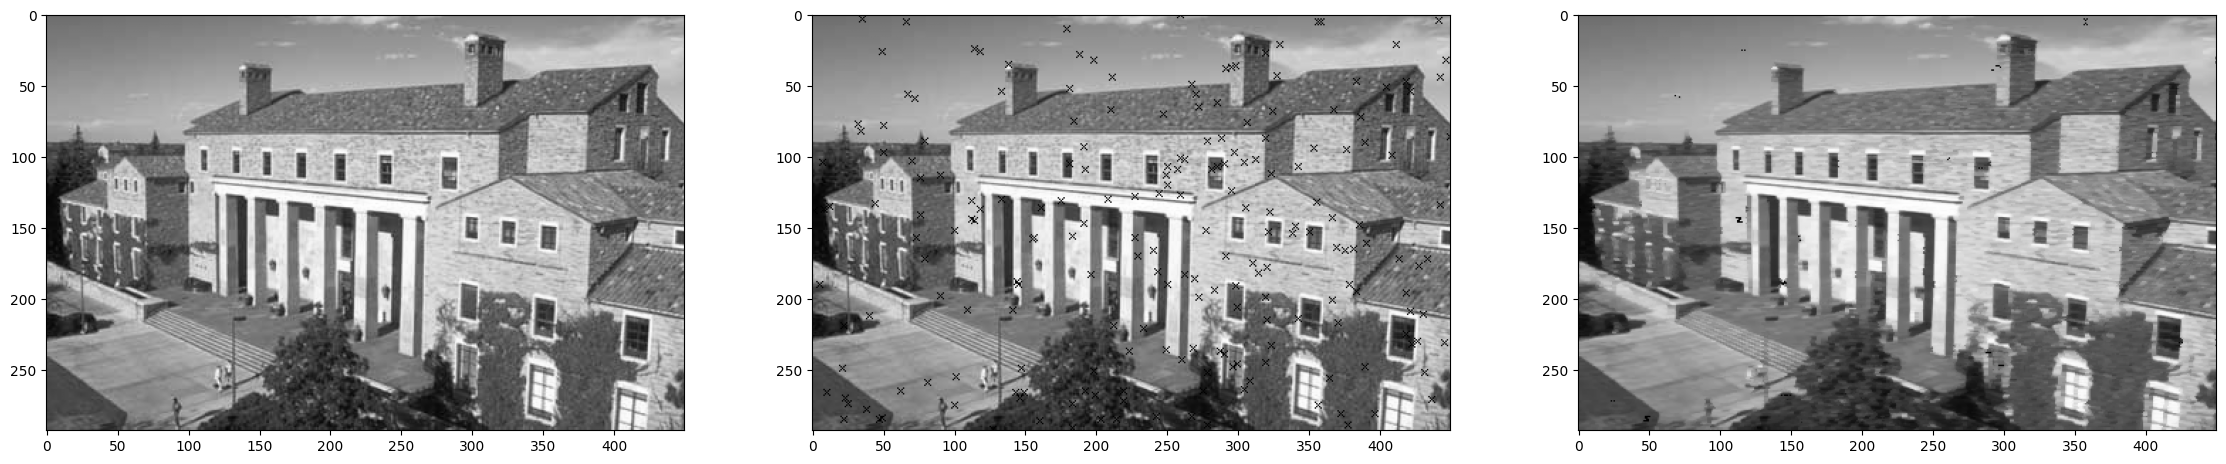

In [12]:
img_e, img_n = shapes_enhance(img/255)
plot_images(img/255, img_n, img_e)